https://github.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/blob/main/solution.ipynb

In [ ]:
import numpy as np
import missingno as msno
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score ,confusion_matrix, classification_report, ConfusionMatrixDisplay

# **0. CONTEXTO Y CARGA DATOS**

**Objetivo**:

Entrena un modelo de K-Vecinos más Cercanos (KNN) para predecir la calidad de un vino tinto a partir de sus características químicas con el objetivo de recomendar a cada individuo un determinado vino.

**Variables**: 

- fixed acidity, volatile acidity, citric acid

- residual sugar, chlorides

- free sulfur dioxide, total sulfur dioxide

- density, pH, sulphates, alcohol

In [2]:
#Cargamos la base de datos en crudo
df=pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv", sep=";")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [3]:
df.head(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.0,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5


# 1. Prepocesamiento de datos

## 1.1. Verificar valores

### 1.1.1. Unicos

In [4]:
# Valores unicos por cada columna
unicos=df.nunique()
print("No hay columnas con valores únicos" if sum(unicos==1)==0 else "Hay columnas con valores únicos")

No hay columnas con valores únicos


### 1.1.2. Eliminación de filas y columnas duplicadas

In [5]:
fil_dup=df.duplicated(keep="last") # keep=last: Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

Hay 240 filas duplicadas


In [6]:
#Mostramos un df con todas las filas duplicadas
todas=df.duplicated(keep=False)
df.iloc[todas[todas==True].index].T

,0,4,9,11,22,27,39,40,64,65,...,1560,1561,1562,1563,1564,1567,1579,1581,1592,1596
fixed acidity,7.4000,7.4000,7.5000,7.5000,7.9000,7.9000,7.3000,7.3000,7.2000,7.2000,...,7.80000,7.80000,7.20000,7.20000,7.20000,7.20000,6.20000,6.20000,6.30000,6.30000
volatile acidity,0.7000,0.7000,0.5000,0.5000,0.4300,0.4300,0.4500,0.4500,0.7250,0.7250,...,0.60000,0.60000,0.69500,0.69500,0.69500,0.69500,0.56000,0.56000,0.51000,0.51000
citric acid,0.0000,0.0000,0.3600,0.3600,0.2100,0.2100,0.3600,0.3600,0.0500,0.0500,...,0.26000,0.26000,0.13000,0.13000,0.13000,0.13000,0.09000,0.09000,0.13000,0.13000
residual sugar,1.9000,1.9000,6.1000,6.1000,1.6000,1.6000,5.9000,5.9000,4.6500,4.6500,...,2.00000,2.00000,2.00000,2.00000,2.00000,2.00000,1.70000,1.70000,2.30000,2.30000
chlorides,0.0760,0.0760,0.0710,0.0710,0.1060,0.1060,0.0740,0.0740,0.0860,0.0860,...,0.08000,0.08000,0.07600,0.07600,0.07600,0.07600,0.05300,0.05300,0.07600,0.07600
free sulfur dioxide,11.0000,11.0000,17.0000,17.0000,10.0000,10.0000,12.0000,12.0000,4.0000,4.0000,...,31.00000,31.00000,12.00000,12.00000,12.00000,12.00000,24.00000,24.00000,29.00000,29.00000
total sulfur dioxide,34.0000,34.0000,102.0000,102.0000,37.0000,37.0000,87.0000,87.0000,11.0000,11.0000,...,131.00000,131.00000,20.00000,20.00000,20.00000,20.00000,32.00000,32.00000,40.00000,40.00000
density,0.9978,0.9978,0.9978,0.9978,0.9966,0.9966,0.9978,0.9978,0.9962,0.9962,...,0.99622,0.99622,0.99546,0.99546,0.99546,0.99546,0.99402,0.99402,0.99574,0.99574
pH,3.5100,3.5100,3.3500,3.3500,3.1700,3.1700,3.3300,3.3300,3.4100,3.4100,...,3.21000,3.21000,3.29000,3.29000,3.29000,3.29000,3.54000,3.54000,3.42000,3.42000
sulphates,0.5600,0.5600,0.8000,0.8000,0.9100,0.9100,0.8300,0.8300,0.3900,0.3900,...,0.52000,0.52000,0.54000,0.54000,0.54000,0.54000,0.60000,0.60000,0.75000,0.75000


In [7]:
#Eliminamos las filas duplicadas
df.drop_duplicates(keep="last", inplace=True)
## Verificamos que se han eliminado correctamente
fil_dup=df.duplicated(keep="last") #Fila duplicada ultima aparicion
print("No hay filas duplicadas" if fil_dup.sum()==0 else f"Hay {fil_dup.sum()} filas duplicadas")

No hay filas duplicadas


In [8]:
#Trasponemos las columnas para verificar que toda la fila (variable) no sea igual a otra
col_dup=df.T.duplicated(keep="last")
print("No hay variables exactamente iguales" if col_dup.sum()==0 else f"Hay {fil_dup.sum()} variables exactamente iguales")

No hay variables exactamente iguales


## 1.2. Verificar missing values

In [9]:
#Mostramos columnas con valores nulos
nulos=df.isna().sum()/len(df)*100
nulos[nulos>0.1]

Series([], dtype: float64)

[]

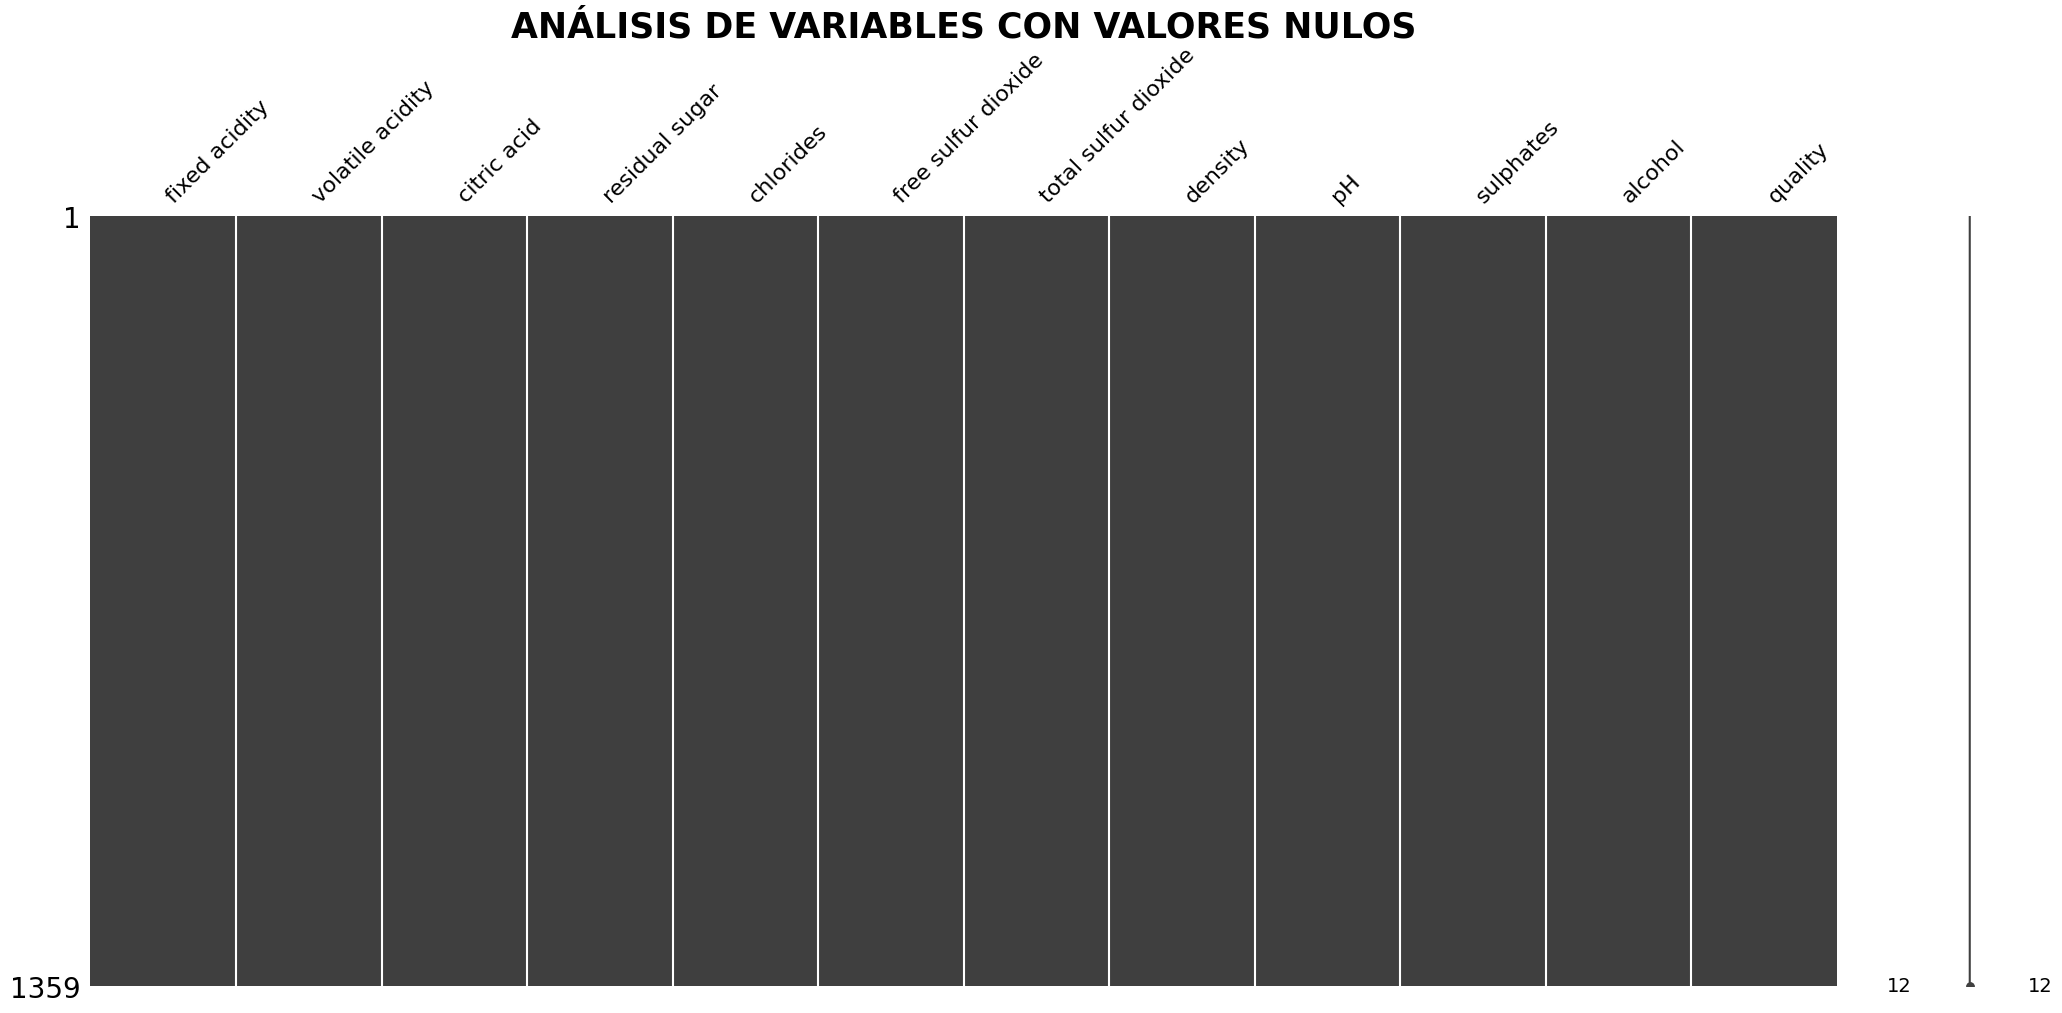

In [10]:
#Gráficamente
msno.matrix(df)
plt.title("ANÁLISIS DE VARIABLES CON VALORES NULOS", fontweight="bold", size=25)
plt.plot()

## 1.4. Análisis Gráfico

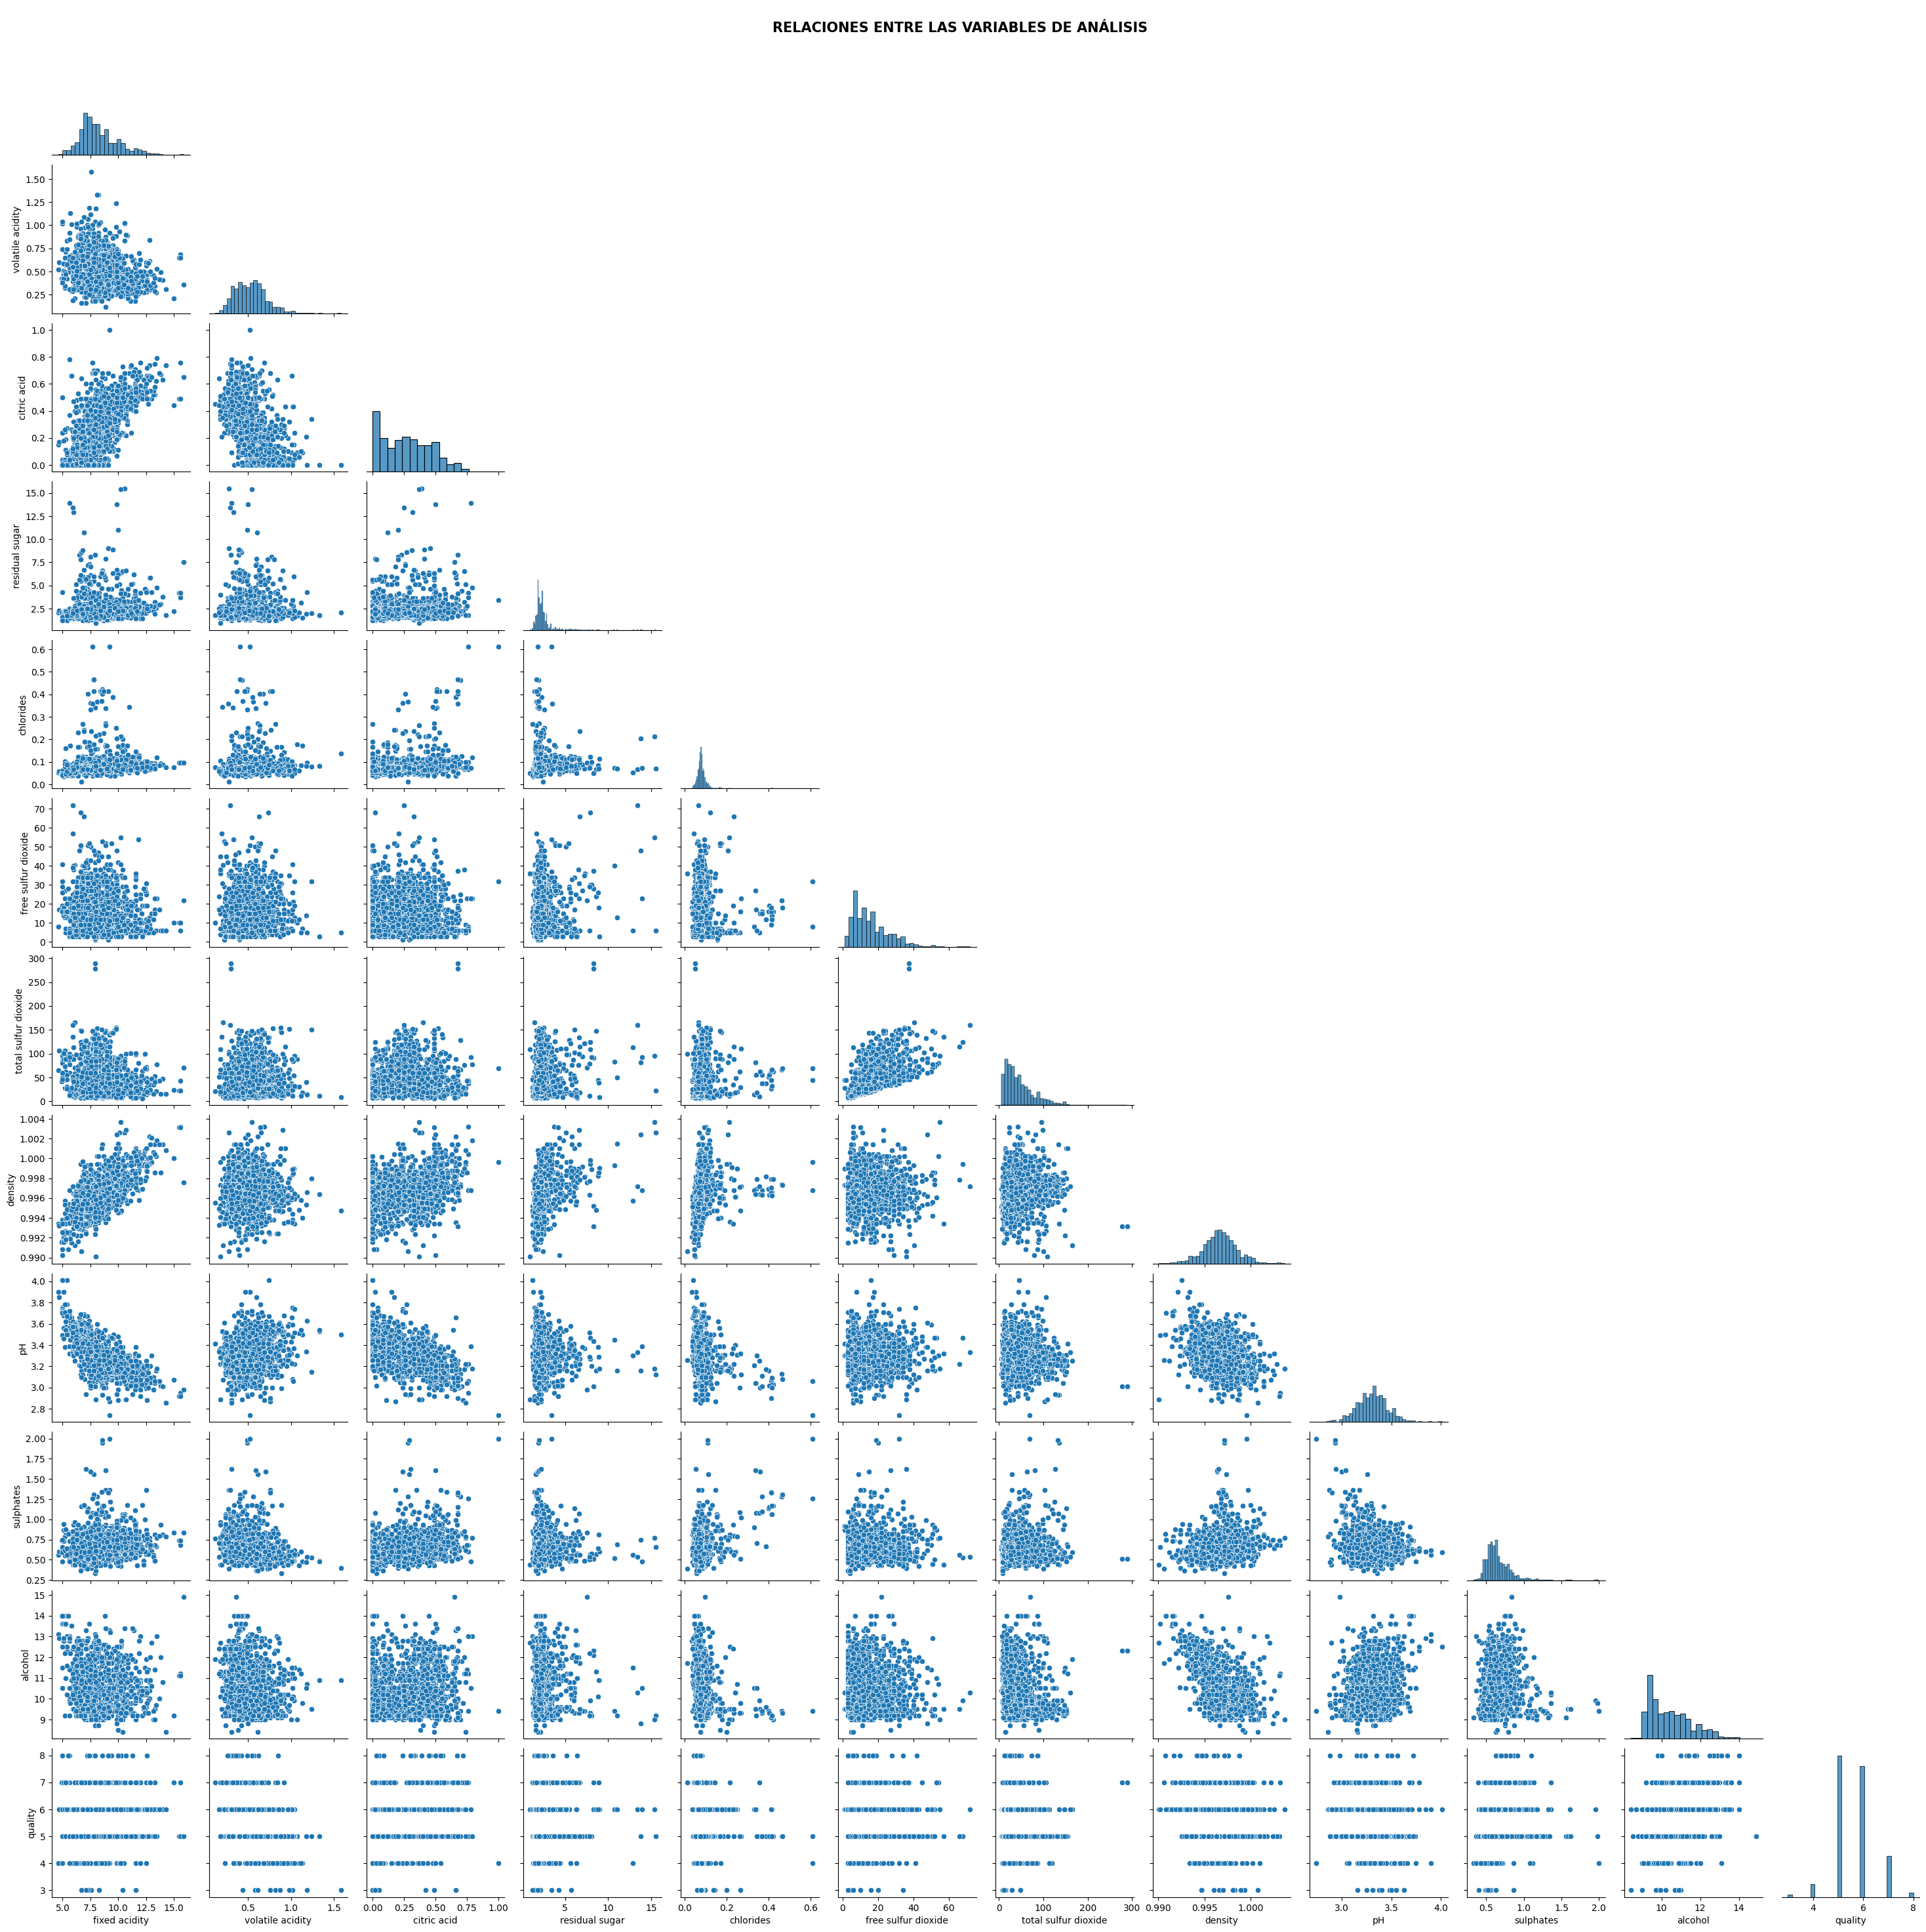

In [11]:
sns.pairplot(data=df, corner=True)
plt.suptitle("Relaciones entre las variables de análisis".upper(), fontweight="bold", size=15)
plt.show()

Se aprecia como algunas variables presentan valores extremos, lo cual será tratado con un escalado.

## 1.5. División train-test

In [12]:
#Configuración previa de quality
df["quality_cod"]=0 #Inicializamos la variable con 0
df.loc[df["quality"]<=4, "quality_cod"]=1
df.loc[(df["quality"]>4)&(df["quality"]<=6), "quality_cod"]=2
df.loc[df["quality"]>=7, "quality_cod"]=3

df["quality_cod"].value_counts().sort_index(ascending=True)

quality_cod
1      63
2    1112
3     184
Name: count, dtype: int64

In [13]:
#Diviisón de la base de datos
X = df.drop(['quality', 'quality_cod'],axis=1)
y = df['quality_cod']
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42) 
X_train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
1016,8.9,0.38,0.40,2.2,0.068,12.0,28.0,0.99486,3.27,0.75,12.60
1521,6.9,0.48,0.20,1.9,0.082,9.0,23.0,0.99585,3.39,0.43,9.05
452,6.8,0.56,0.03,1.7,0.084,18.0,35.0,0.99680,3.44,0.63,10.00
848,6.4,0.64,0.21,1.8,0.081,14.0,31.0,0.99689,3.59,0.66,9.80
58,7.8,0.59,0.18,2.3,0.076,17.0,54.0,0.99750,3.43,0.59,10.00


## 1.6. Escalado

Como las características no están en la misma escala, aquellas con magnitudes más grandes pueden dominar la distancia y afectar el resultado del algoritmo. Por lo tanto, aplicaremos un ``MinMaxScaler`` para homogeneizar las magnitudes de las variables. 

In [14]:
# Instaciamos el escalador
scal=MinMaxScaler()
# Ajustamos y transformamos para train
X_train_sc=pd.DataFrame(scal.fit_transform(X_train), columns=X_train.columns)
# Solo transformamos para test (independia base datos)
X_test_sc=pd.DataFrame(scal.transform(X_test), columns=X_test.columns)

In [15]:
X_train_sc.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000,1087.000000
mean,0.328541,0.278594,0.272677,0.112396,0.129042,0.198410,0.145117,0.487697,0.447493,0.197142,0.312681
std,0.154009,0.122608,0.194711,0.097421,0.086688,0.149451,0.118124,0.137237,0.120331,0.103839,0.166900
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.221239,0.184932,0.100000,0.068493,0.096828,0.071429,0.056537,0.406021,0.370079,0.131737,0.169231
50%,0.292035,0.273973,0.260000,0.089041,0.111853,0.171429,0.113074,0.488253,0.448819,0.173653,0.261538
75%,0.398230,0.356164,0.420000,0.116438,0.131886,0.271429,0.204947,0.567548,0.519685,0.239521,0.415385
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 1.7. Entrenamiento modelo

In [16]:
# Instanciamos y entrenamos el modelo
model = KNeighborsClassifier(n_neighbors=5, #Vecinos más cercanos
                             weights="distance", #vecinos más cercanos tienen más peso
                             metric='minkowski', #métrica lineal
                             p=2) #euclidiana
model.fit(X_train_sc, y_train)

,n_neighbors,5
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


# 2. Evaluación modelo KNN

In [17]:
# Realizamos las predicciones
y_hat_train=model.predict(X_train_sc)
y_hat_test=model.predict(X_test_sc)

In [18]:
#Accuracy
print(f"Porcentaje total de clasificados correctamente: {round(accuracy_score(y_test, y_hat_test)*100,2)}%")
print("="*55)
print("Métricas de clasificación:\n", classification_report(y_test, y_hat_test))
print("="*55)
print(f"Distribución de las categorias: \n {pd.concat([y_test.value_counts(), round(y_train.value_counts(normalize=True), 4)], 
          axis=1, keys=["Observado", "Porcentaje"]).sort_index(ascending=True)}")

Porcentaje total de clasificados correctamente: 84.19%
Métricas de clasificación:
               precision    recall  f1-score   support

           1       0.00      0.00      0.00        13
           2       0.88      0.93      0.91       226
           3       0.56      0.55      0.55        33

    accuracy                           0.84       272
   macro avg       0.48      0.49      0.49       272
weighted avg       0.80      0.84      0.82       272

Distribución de las categorias: 
              Observado  Porcentaje
quality_cod                       
1                   13      0.0460
2                  226      0.8151
3                   33      0.1389


A priori, podríamos afirmar que el modelo captura correctamente la distribución de los datos pues clasifica correctamente al 84,19% de las diferentes categorías de vinos en la base de datos de test.

Sin embargo, profundizando en las métricas de clasificación y en la distribución de las categorías de vino, podemos observar como el hecho de tener un desbalance importante entre las categorías está causando un ajuste muy pobre para los grupos minoritarios (0% y 55% de f1-score para los vinos de baja y alta calidad) y bastante alto para el grupo mayoritario (91% de f1-score para vinos de calidad media).

Todo esto se aprecia en la matriz de confusión, que mostraremos en terminos unitarios respecto a los valores observados.

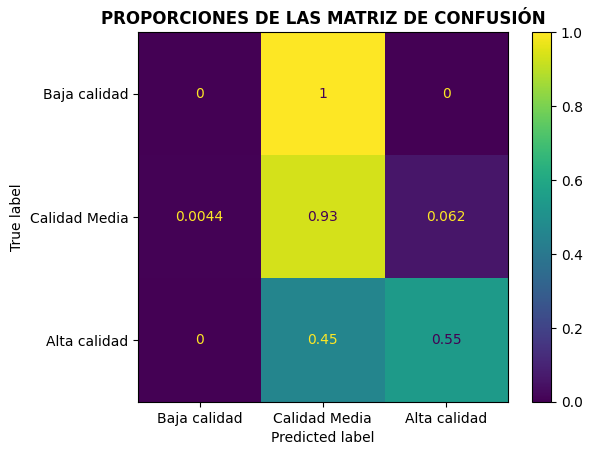

In [101]:
#Matriz de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_hat_test, normalize="true"),  display_labels=["Baja calidad", "Calidad Media", "Alta calidad"])
disp.plot()
plt.title("Proporciones de las matriz de confusión".upper(), fontweight="bold")
plt.show()

In [135]:
pd.concat([y_test.value_counts(), pd.Series(y_hat_test).value_counts()], 
          axis=1, keys=["Observado", "Predicho"]).sort_index(ascending=True)

,Observado,Predicho
1,13,1
2,226,239
3,33,32


De esta forma, podemos evidenciar que el modelo esta clasificando vinos de baja y alta calidad como vino de calida mediay algunos de alta calida como media.

# 3. Optimización de hiperparámetros

En este caso, testaremos si el uso de diferentes métricas de numero de vecinos o de cálculo de distancias permiten mejorar las predicciones.

In [50]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

# Definimos el rango de parámetros a probar
param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='recall')
grid_search.fit(X_train_sc, y_train)

print(f"Mejor configuración: {grid_search.best_params_}")

c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                 

Mejor configuración: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:953: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 942, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 308, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\jjime\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_scorer.py", line 408, in _score
    return self._sign * self._score_func(y_true, y_pred, **scoring_kwargs)
                 

In [48]:
y_hat1=grid_search.predict(X_train_sc)
y_hat2=grid_search.predict(X_test_sc)

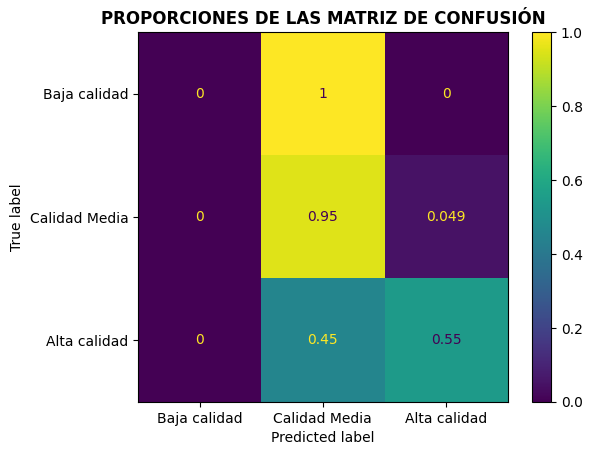

In [49]:
#Matriz de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_hat2, normalize="true"),  display_labels=["Baja calidad", "Calidad Media", "Alta calidad"])
disp.plot()
plt.title("Proporciones de las matriz de confusión".upper(), fontweight="bold")
plt.show()